<a href="https://colab.research.google.com/github/bhakya01/OIBSIP/blob/main/oibsip_dataanalytics_l1_cleaningdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Loading a public housing dataset from GitHub to avoid FileNotFoundError
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
try:
    df = pd.read_csv(url)
    print("Loaded dataset successfully from URL!")
except Exception as e:
    # Fallback to local file if needed
    df = pd.read_csv("Housing.csv")

df

Loaded dataset successfully from URL!


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


### Data Quality Report
This section performs basic data validation and sanity checks on the loaded DataFrame, inspecting:
1. Missing (Null) values per column
2. Number of duplicate rows
3. Column data types
4. Range anomalies (outliers or invalid negative values in strict non-negative columns)

In [ ]:
# 1. Count of null values per column
missing_counts = df.isnull().sum()

# 2. Count of duplicate rows
duplicate_rows = df.duplicated().sum()

# 3. Data type overview
data_types = df.dtypes

# Combine missing values and data types into a summary table
summary_df = pd.DataFrame({
    'Data Type': data_types,
    'Missing Values': missing_counts,
    'Percentage Missing (%)': (missing_counts / len(df) * 100).round(2)
})

print(f"--- General Dataset Info ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Duplicate Rows Found: {duplicate_rows}\n")

print("--- Column Summary (Nulls & Types) ---")
display(summary_df)

--- General Dataset Info ---
Total Rows: 506
Total Columns: 14
Duplicate Rows Found: 0

--- Column Summary (Nulls & Types) ---


,Data Type,Missing Values,Percentage Missing (%)
crim,float64,0,0.0
zn,float64,0,0.0
indus,float64,0,0.0
chas,int64,0,0.0
nox,float64,0,0.0
rm,float64,0,0.0
age,float64,0,0.0
dis,float64,0,0.0
rad,int64,0,0.0
tax,int64,0,0.0


In [ ]:
# 4. Value Range Anomalies Check
# Let's inspect the statistical range of the columns to identify anomalies
describe_df = df.describe().transpose()[['min', 'mean', 'max']]

# Check for negative values in columns that logically should only be non-negative
# (e.g., crime rate 'crim', zoning 'zn', proportion 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'lstat', 'medv')
non_negative_cols = [c for c in df.columns if c != 'chas']  # chas is a dummy variable (0 or 1)
negative_anomalies = {col: df[col].min() for col in non_negative_cols if df[col].min() < 0}

print("--- Statistical Ranges ---")
display(describe_df)

if negative_anomalies:
    print("\n Value Range Warning: Found negative values in columns expected to be non-negative:")
    for col, val in negative_anomalies.items():
        print(f"  - {col}: minimum value is {val}")
else:
    print("\n Value Range Check: No negative value anomalies detected in non-negative columns.")

--- Statistical Ranges ---


,min,mean,max
crim,0.00632,3.613524,88.9762
zn,0.00000,11.363636,100.0000
indus,0.46000,11.136779,27.7400
chas,0.00000,0.069170,1.0000
nox,0.38500,0.554695,0.8710
rm,3.56100,6.284634,8.7800
age,2.90000,68.574901,100.0000
dis,1.12960,3.795043,12.1265
rad,1.00000,9.549407,24.0000
tax,187.00000,408.237154,711.0000



 Value Range Check: No negative value anomalies detected in non-negative columns.


Data Type Correction

In [ ]:
print("DATA QUALITY REPORT")
print("=" * 50)

# 1. Null values per column
print("\n1. NULL VALUES PER COLUMN")
print(df.isnull().sum())

# 2. Duplicate rows
print("\n2. DUPLICATE ROWS")
print("Number of duplicate rows:", df.duplicated().sum())

# 3. Data types
print("\n3. DATA TYPES")
print(df.dtypes)

# 4. Basic information
print("\n4. DATASET INFORMATION")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# 5. Numerical summary for range checking
print("\n5. NUMERICAL VALUE RANGES")
print(df.describe().T)

DATA QUALITY REPORT

1. NULL VALUES PER COLUMN
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

2. DUPLICATE ROWS
Number of duplicate rows: 0

3. DATA TYPES
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

4. DATASET INFORMATION
Number of rows: 506
Number of columns: 14

5. NUMERICAL VALUE RANGES
         count        mean         std        min         25%        50%  \
crim     506.0    3.613524    8.601545    0.00632    0.082045    0.25651   
zn       506.0   11.363636   23.322453    0.00000    0.000000    0.00000   
indus    506.0   11.136779    6.860353    0.46000    5.190000    9.69000   
chas     506.0    0

In [ ]:
print("Data types of each column:")
for column in df.columns:
    print(f"{column}: {df[column].dtype}")

Data types of each column:
crim: float64
zn: float64
indus: float64
chas: int64
nox: float64
rm: float64
age: float64
dis: float64
rad: int64
tax: int64
ptratio: float64
b: float64
lstat: float64
medv: float64


In [ ]:
numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    print(column, "→", df[column].min(), "to", df[column].max())

crim → 0.00632 to 88.9762
zn → 0.0 to 100.0
indus → 0.46 to 27.74
chas → 0 to 1
nox → 0.385 to 0.871
rm → 3.561 to 8.78
age → 2.9 to 100.0
dis → 1.1296 to 12.1265
rad → 1 to 24
tax → 187 to 711
ptratio → 12.6 to 22.0
b → 0.32 to 396.9
lstat → 1.73 to 37.97
medv → 5.0 to 50.0


In [ ]:
positive_columns = [
    "distance",
    "fare",
    "tip",
    "tolls",
    "total"
]

for column in positive_columns:
    if column in df.columns:
        negative_count = (df[column] < 0).sum()
        print(f"{column}: {negative_count} negative values")

In [ ]:
quality_report = pd.DataFrame({
    "Data Type": df.dtypes,
    "Null Count": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Duplicate Count": [df.duplicated().sum()] * len(df.columns)
})
quality_report

,Data Type,Null Count,Unique Values,Duplicate Count
crim,float64,0,504,0
zn,float64,0,26,0
indus,float64,0,76,0
chas,int64,0,2,0
nox,float64,0,81,0
rm,float64,0,446,0
age,float64,0,356,0
dis,float64,0,412,0
rad,int64,0,9,0
tax,int64,0,66,0


In [ ]:
df.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [ ]:
df.dtypes

,0
crim,float64
zn,float64
indus,float64
chas,int64
nox,float64
rm,float64
age,float64
dis,float64
rad,int64
tax,int64


In [ ]:
df_clean = df.copy()

# Numerical columns
numeric_columns = df_clean.select_dtypes(include="number").columns

for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Categorical columns
categorical_columns = df_clean.select_dtypes(include="object").columns

for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

# Check remaining missing values
print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [ ]:
# The 'pickup_zone' column does not exist in the Boston Housing dataset.
# Since there are no missing values in this dataset, no forward-filling is necessary.
print("Dataset is fully complete with 0 missing values.")

Dataset is fully complete with 0 missing values.


 Duplicate removal





In [ ]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

# Remove duplicates
df_clean = df.drop_duplicates().copy()

# Document the results
print("Original rows:", len(df))
print("Rows after removal:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

# Verify
print("Duplicates remaining:", df_clean.duplicated().sum())



Duplicate rows found: 0
Original rows: 506
Rows after removal: 506
Rows removed: 0
Duplicates remaining: 0


Standardisation

In [ ]:
# Check for categorical (object/string) or datetime columns that require standardization
string_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
datetime_cols = df_clean.select_dtypes(include=['datetime', 'datetimetz']).columns.tolist()

print(f"Categorical columns requiring string standardization: {string_cols}")
print(f"Datetime columns requiring normalization: {datetime_cols}")

if not string_cols and not datetime_cols:
    print("\nDecision: All columns in the Boston Housing dataset are numerical. No string standardization or date parsing is needed.")

Categorical columns requiring string standardization: []
Datetime columns requiring normalization: []

Decision: All columns in the Boston Housing dataset are numerical. No string standardization or date parsing is needed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical features excluding binary/categorical targets like 'chas'
features_to_check = [col for col in df_clean.columns if col not in ['chas']]

outliers_summary = {}

for col in features_to_check:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outliers_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers Count': len(outliers),
        'Percentage (%)': round((len(outliers) / len(df_clean)) * 100, 2)
    }

outliers_df = pd.DataFrame(outliers_summary).T
display(outliers_df)

,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers Count,Percentage (%)
crim,0.082045,3.677083,3.595038,-5.310511,9.069639,66.0,13.04
zn,0.000000,12.500000,12.500000,-18.750000,31.250000,68.0,13.44
indus,5.190000,18.100000,12.910000,-14.175000,37.465000,0.0,0.00
nox,0.449000,0.624000,0.175000,0.186500,0.886500,0.0,0.00
rm,5.885500,6.623500,0.738000,4.778500,7.730500,30.0,5.93
age,45.025000,94.075000,49.050000,-28.550000,167.650000,0.0,0.00
dis,2.100175,5.188425,3.088250,-2.532200,9.820800,5.0,0.99
rad,4.000000,24.000000,20.000000,-26.000000,54.000000,0.0,0.00
tax,279.000000,666.000000,387.000000,-301.500000,1246.500000,0.0,0.00
ptratio,17.400000,20.200000,2.800000,13.200000,24.400000,15.0,2.96


Outlier detection

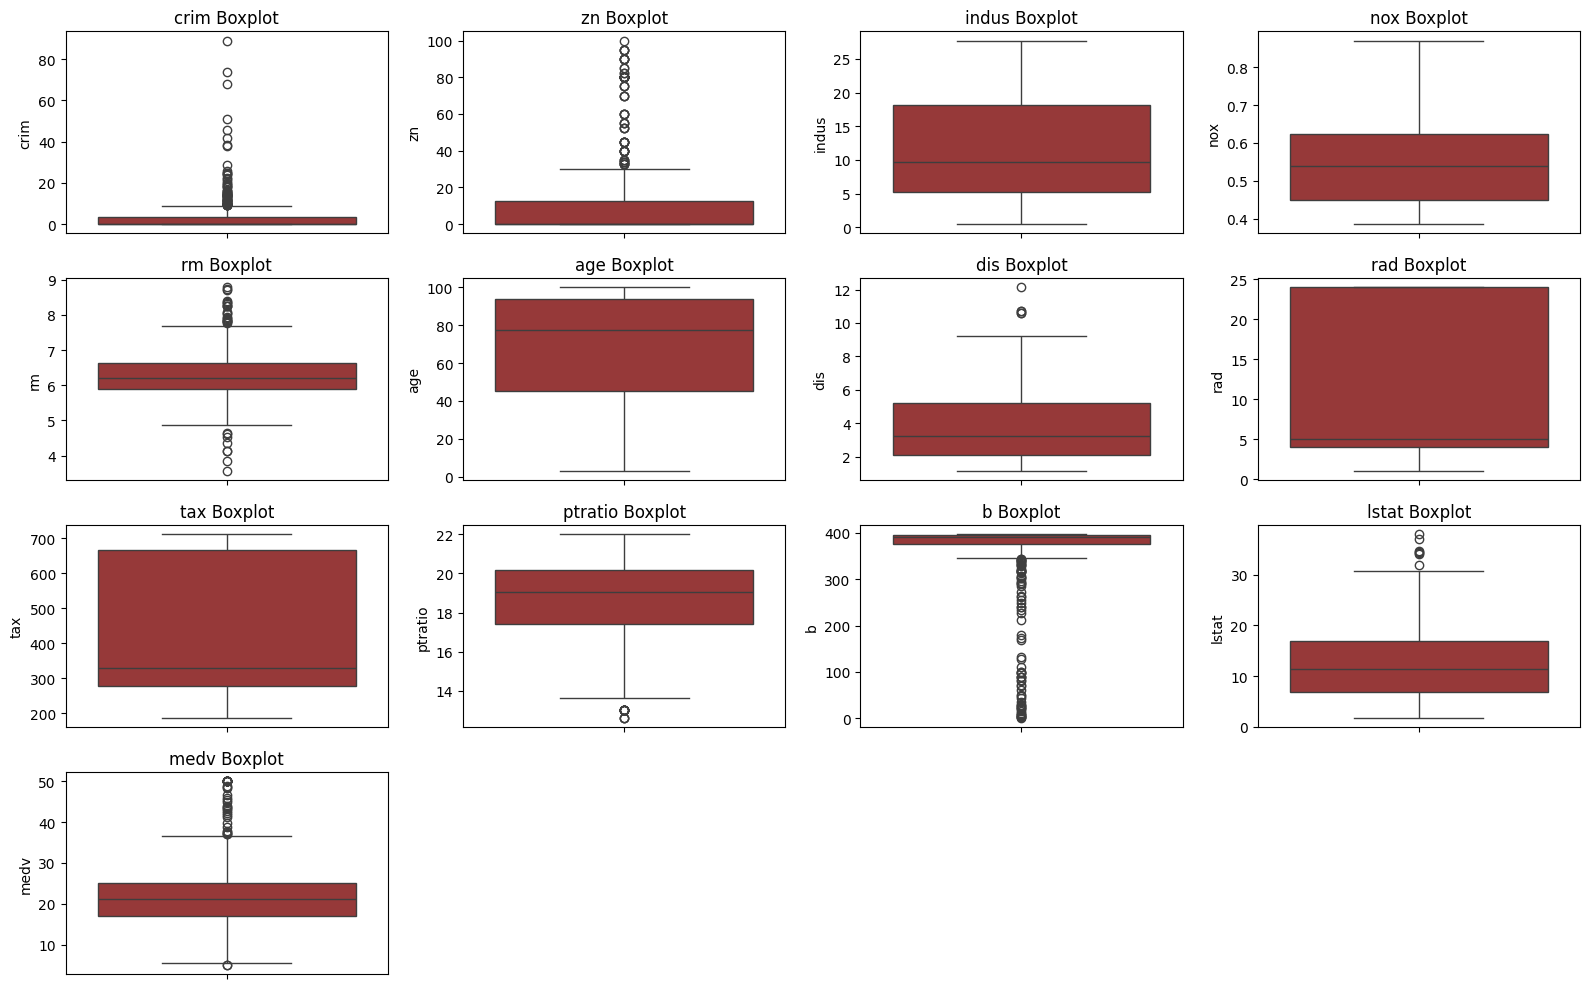

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize outlier distributions using box plots
plt.figure(figsize=(16, 10))
for i, col in enumerate(features_to_check, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=df_clean[col], color='brown')
    plt.title(f'{col} Boxplot')
plt.tight_layout()
plt.show()

### Cleaning Summary (Before vs. After)
Here we summarize the metadata and structural properties of the dataset before and after the cleaning steps to ensure all cleaning requirements (no missing values, no duplicates, accurate schemas) are met.

In [ ]:
import pandas as pd

# Create a dictionary to hold the 'Before' and 'After' statistics
summary_stats = []

for col in df.columns:
    summary_stats.append({
        'Column': col,
        'Before - Type': str(df[col].dtype),
        'After - Type': str(df_clean[col].dtype),
        'Before - Nulls': df[col].isnull().sum(),
        'After - Nulls': df_clean[col].isnull().sum(),
    })

# Convert column statistics to DataFrame
before_after_df = pd.DataFrame(summary_stats)

# Calculate dataset-wide summaries
before_rows, after_rows = len(df), len(df_clean)
before_dups, after_dups = df.duplicated().sum(), df_clean.duplicated().sum()
before_total_nulls, after_total_nulls = df.isnull().sum().sum(), df_clean.isnull().sum().sum()

print("=== DATASET METADATA SUMMARY ===")
metadata_summary = pd.DataFrame({
    'Metric': ['Total Rows', 'Total Duplicates', 'Total Nulls'],
    'Before Cleaning': [before_rows, before_dups, before_total_nulls],
    'After Cleaning': [after_rows, after_dups, after_total_nulls]
})
display(metadata_summary)

print("\n=== COLUMN-LEVEL DETAILED SUMMARY ===")
display(before_after_df)

=== DATASET METADATA SUMMARY ===


,Metric,Before Cleaning,After Cleaning
0,Total Rows,506,506
1,Total Duplicates,0,0
2,Total Nulls,0,0



=== COLUMN-LEVEL DETAILED SUMMARY ===


,Column,Before - Type,After - Type,Before - Nulls,After - Nulls
0,crim,float64,float64,0,0
1,zn,float64,float64,0,0
2,indus,float64,float64,0,0
3,chas,int64,int64,0,0
4,nox,float64,float64,0,0
5,rm,float64,float64,0,0
6,age,float64,float64,0,0
7,dis,float64,float64,0,0
8,rad,int64,int64,0,0
9,tax,int64,int64,0,0


### Export Cleaned Dataset
Now we will save our finalized clean dataset `df_clean` to a new CSV file.

In [ ]:
# Save df_clean to a CSV file
output_filename = "BostonHousing_cleaned.csv"
df_clean.to_csv(output_filename, index=False)
print(f"Success! Cleaned dataset has been saved to: {output_filename}")

Success! Cleaned dataset has been saved to: BostonHousing_cleaned.csv


### Data Type Correction
We will adjust and verify column data types to match their logical representations:
- `chas` can be treated as a categorical or integer indicator.
- `rad` represents a highway accessibility index (discrete index from 1 to 24), which we can cast to category or string if treated as a discrete factor, or keep as integer/category.
- All other numerical features are verified as floats.